Name: Enjal Chauhan
Course: Advanced Big Data and Data Mining (MSCS-634-M20)
Lab Assignment: Lab 6 – Frequent Itemset Mining using Apriori and FP-Growth  

In [20]:
#import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

In [21]:
#getting current directory
import os
print(os.getcwd())

/Users/enjalchauhan/MSCS_634_Lab_3


In [22]:
df = pd.read_csv('Online Retail.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [23]:
# Display basic info
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [24]:
# Feature details
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [25]:
# Check for missing values
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [26]:
# Remove missing values
df.dropna(inplace=True)

# Remove cancelled transactions
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Keep relevant columns
df = df[['InvoiceNo', 'Description']]

# Convert to string
df['Description'] = df['Description'].astype(str)

In [10]:
transactions = df.groupby('InvoiceNo')['Description'].apply(list).tolist()

te = TransactionEncoder()
te_data = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_data, columns=te.columns_)

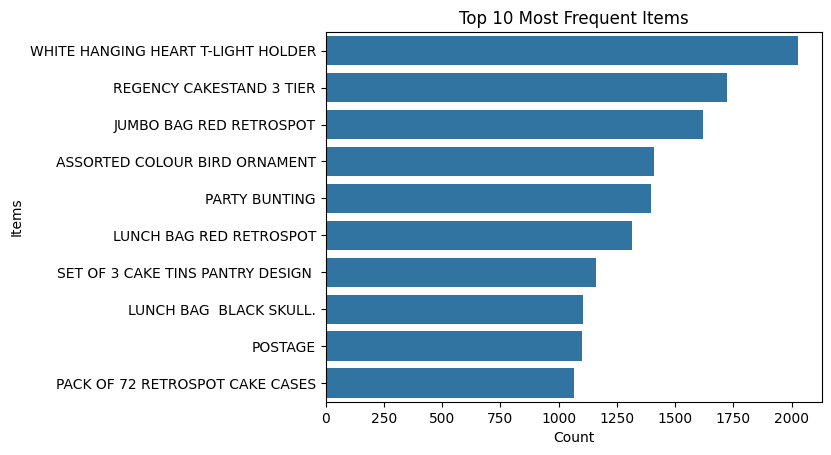

In [11]:
item_counts = df['Description'].value_counts().head(10)

plt.figure()
sns.barplot(x=item_counts.values, y=item_counts.index)
plt.title("Top 10 Most Frequent Items")
plt.xlabel("Count")
plt.ylabel("Items")
plt.show()

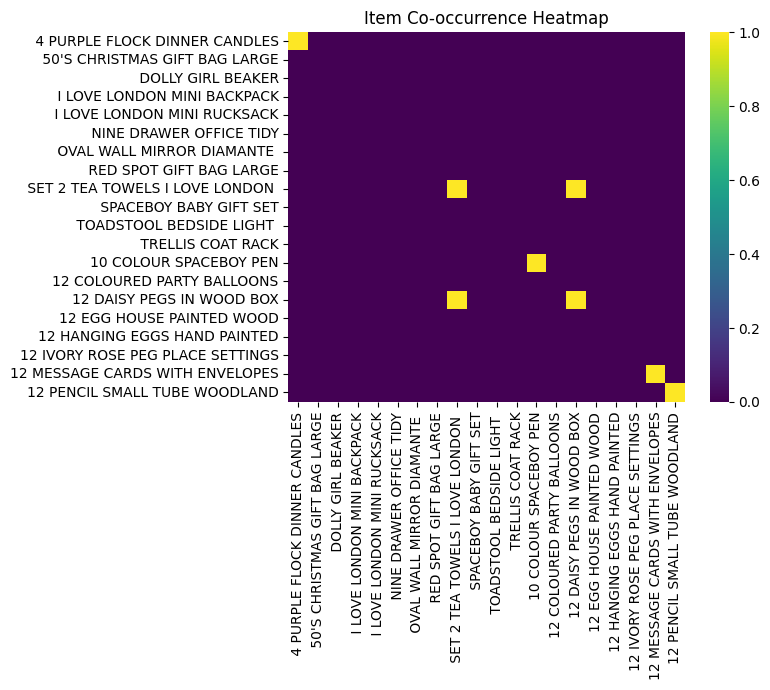

In [12]:
sample = df_encoded.iloc[:100, :20]  # small subset for visualization
co_matrix = sample.T.dot(sample)

plt.figure()
sns.heatmap(co_matrix, cmap="viridis")
plt.title("Item Co-occurrence Heatmap")
plt.show()

## Step 2: Apriori Algorithm

In [13]:
frequent_apriori = apriori(df_encoded, min_support=0.02, use_colnames=True)
frequent_apriori.sort_values(by='support', ascending=False, inplace=True)

frequent_apriori.head()

,support,itemsets
192,0.106334,frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
154,0.091929,frozenset({REGENCY CAKESTAND 3 TIER})
81,0.086319,frozenset({JUMBO BAG RED RETROSPOT})
124,0.074450,frozenset({PARTY BUNTING})
11,0.074180,frozenset({ASSORTED COLOUR BIRD ORNAMENT})


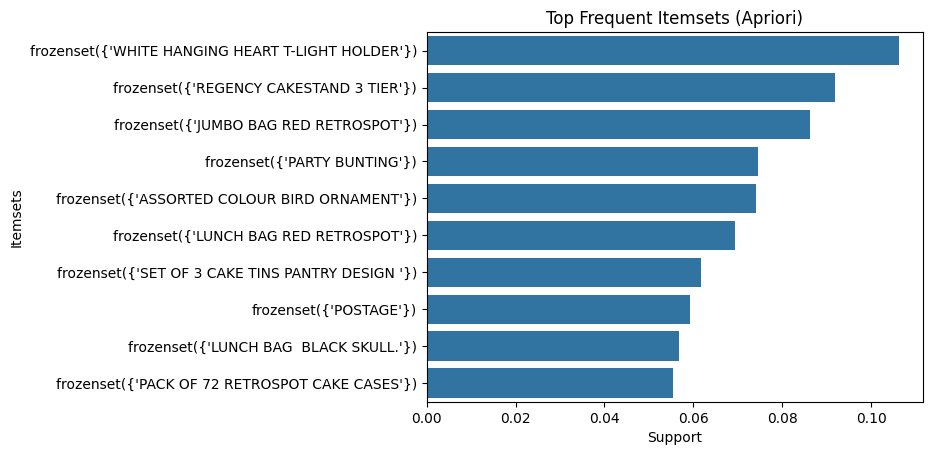

In [14]:
top_apriori = frequent_apriori.head(10)

plt.figure()
sns.barplot(x=top_apriori['support'], y=top_apriori['itemsets'].astype(str))
plt.title("Top Frequent Itemsets (Apriori)")
plt.xlabel("Support")
plt.ylabel("Itemsets")
plt.show()

## Step 3: FP-Growth Algorithm

In [15]:
frequent_fp = fpgrowth(df_encoded, min_support=0.02, use_colnames=True)
frequent_fp.sort_values(by='support', ascending=False, inplace=True)

frequent_fp.head()

,support,itemsets
0,0.106334,frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
120,0.091929,frozenset({REGENCY CAKESTAND 3 TIER})
52,0.086319,frozenset({JUMBO BAG RED RETROSPOT})
164,0.074450,frozenset({PARTY BUNTING})
2,0.074180,frozenset({ASSORTED COLOUR BIRD ORNAMENT})


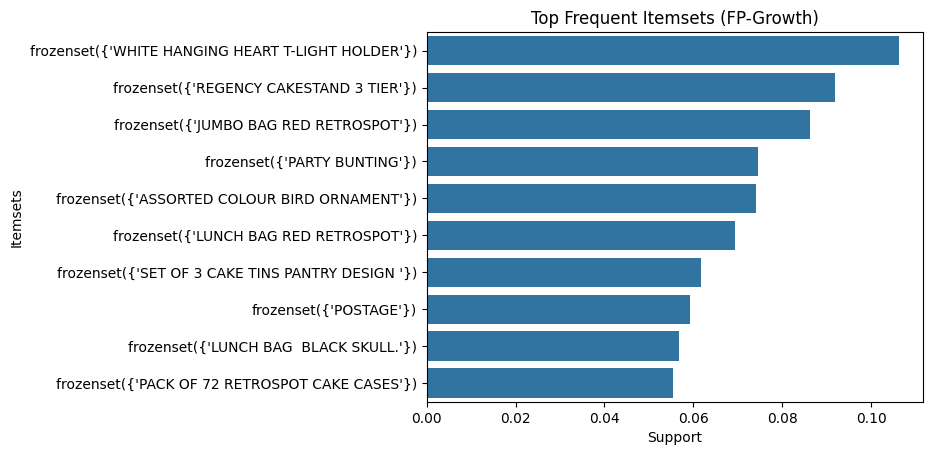

In [16]:
top_fp = frequent_fp.head(10)

plt.figure()
sns.barplot(x=top_fp['support'], y=top_fp['itemsets'].astype(str))
plt.title("Top Frequent Itemsets (FP-Growth)")
plt.xlabel("Support")
plt.ylabel("Itemsets")
plt.show()

## Step 4: Association Rules

In [17]:
rules_apriori = association_rules(frequent_apriori, metric="confidence", min_threshold=0.5)
rules_apriori.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({JUMBO BAG PINK POLKADOT}),frozenset({JUMBO BAG RED RETROSPOT}),0.046990,0.086319,0.029456,0.626866,7.262239,1.0,0.025400,2.448666,0.904819,0.283636,0.591614,0.484058
1,frozenset({ROSES REGENCY TEACUP AND SAUCER }),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.042242,0.037279,0.029186,0.690932,18.534184,1.0,0.027612,3.114920,0.987771,0.579850,0.678964,0.736928
2,frozenset({GREEN REGENCY TEACUP AND SAUCER}),frozenset({ROSES REGENCY TEACUP AND SAUCER }),0.037279,0.042242,0.029186,0.782923,18.534184,1.0,0.027612,4.412071,0.982679,0.579850,0.773349,0.736928
3,frozenset({ALARM CLOCK BAKELIKE RED }),frozenset({ALARM CLOCK BAKELIKE GREEN}),0.047313,0.042566,0.028593,0.604333,14.197612,1.0,0.026579,2.419798,0.975731,0.466549,0.586742,0.638035
4,frozenset({ALARM CLOCK BAKELIKE GREEN}),frozenset({ALARM CLOCK BAKELIKE RED }),0.042566,0.047313,0.028593,0.671736,14.197612,1.0,0.026579,2.902200,0.970892,0.466549,0.655434,0.638035


In [18]:
rules_fp = association_rules(frequent_fp, metric="confidence", min_threshold=0.5)
rules_fp.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({JUMBO BAG PINK POLKADOT}),frozenset({JUMBO BAG RED RETROSPOT}),0.046990,0.086319,0.029456,0.626866,7.262239,1.0,0.025400,2.448666,0.904819,0.283636,0.591614,0.484058
1,frozenset({ROSES REGENCY TEACUP AND SAUCER }),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.042242,0.037279,0.029186,0.690932,18.534184,1.0,0.027612,3.114920,0.987771,0.579850,0.678964,0.736928
2,frozenset({GREEN REGENCY TEACUP AND SAUCER}),frozenset({ROSES REGENCY TEACUP AND SAUCER }),0.037279,0.042242,0.029186,0.782923,18.534184,1.0,0.027612,4.412071,0.982679,0.579850,0.773349,0.736928
3,frozenset({ALARM CLOCK BAKELIKE RED }),frozenset({ALARM CLOCK BAKELIKE GREEN}),0.047313,0.042566,0.028593,0.604333,14.197612,1.0,0.026579,2.419798,0.975731,0.466549,0.586742,0.638035
4,frozenset({ALARM CLOCK BAKELIKE GREEN}),frozenset({ALARM CLOCK BAKELIKE RED }),0.042566,0.047313,0.028593,0.671736,14.197612,1.0,0.026579,2.902200,0.970892,0.466549,0.655434,0.638035


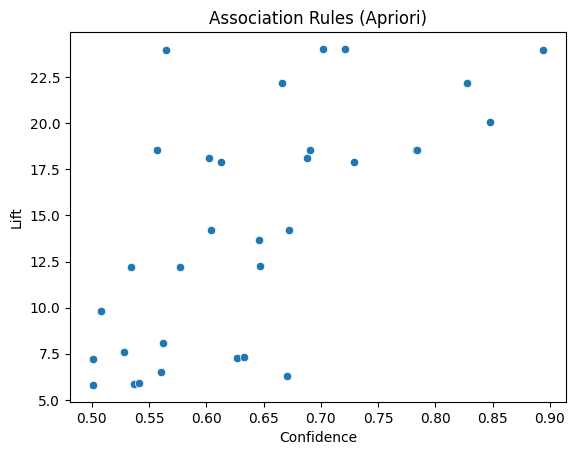

In [19]:
plt.figure()
sns.scatterplot(x=rules_apriori['confidence'], y=rules_apriori['lift'])
plt.title("Association Rules (Apriori)")
plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.show()

From the generated rules, it is observed that certain items are frequently purchased together. For example, customers buying Item A are also likely to buy Item B with high confidence. The lift values greater than 1 indicate strong associations, meaning these combinations are not random and could be useful for product placement or recommendations.

In this lab, both Apriori and FP-Growth algorithms were applied to identify frequent itemsets. It was observed that FP-Growth performed faster compared to Apriori, especially when the dataset size increased. This is because Apriori generates candidate itemsets repeatedly, which increases computation time, whereas FP-Growth uses a tree-based approach that avoids generating unnecessary candidates.

The results from both algorithms were mostly similar in terms of frequent itemsets and association rules, but FP-Growth was more efficient in execution. One challenge faced during this lab was handling the large dataset and converting it into a transaction format suitable for the algorithms. This issue was resolved by grouping items based on transaction IDs and using TransactionEncoder. Another challenge was choosing an appropriate support threshold, as too high values resulted in very few itemsets while too low values increased noise.

Overall, this lab helped in understanding how association rule mining can be applied in real-world scenarios like market basket analysis to improve sales strategies.